# HW#2-10: Morphology를 이용한 텍스처 분할

두 종류의 blob이 혼합된 영상에서 Morphology 연산으로 영역을 분할한다.  
Figure 9.43의 과정을 재현한다:
1. (a) 원본: 크고 작은 두 종류의 blob
2. (b) Closing으로 작은 blob 제거
3. (c) Opening으로 큰 blob 사이의 밝은 gap 제거
4. (d) Morphological Gradient로 경계선 추출 → 원본에 중첩

Image shape: (600, 600), dtype: uint8


[ WARN:0@0.138] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.138] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.138] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.138] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.138] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.138] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.138] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.138] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

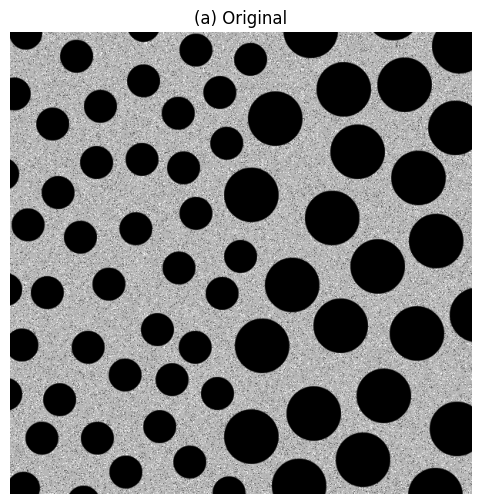

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('data/Fig0943(a)(dark_blobs_on_light_background).tif', cv2.IMREAD_GRAYSCALE)
print(f'Image shape: {img.shape}, dtype: {img.dtype}')

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('(a) Original')
plt.axis('off')
plt.show()

## Step 1: Closing → 작은 blob 제거

Closing(Dilation → Erosion)은 어두운 영역(blob)보다 작은 구멍/간격을 메운다.  
SE가 작은 blob보다 크면, 작은 blob이 배경에 흡수되어 사라진다.

/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66294/2003199194.py:16: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66294/2003199194.py:16: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66294/2003199194.py:16: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66294/2003199194.py:16: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/song/Projects/cv-hw/cv-hw2/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/song/Proje

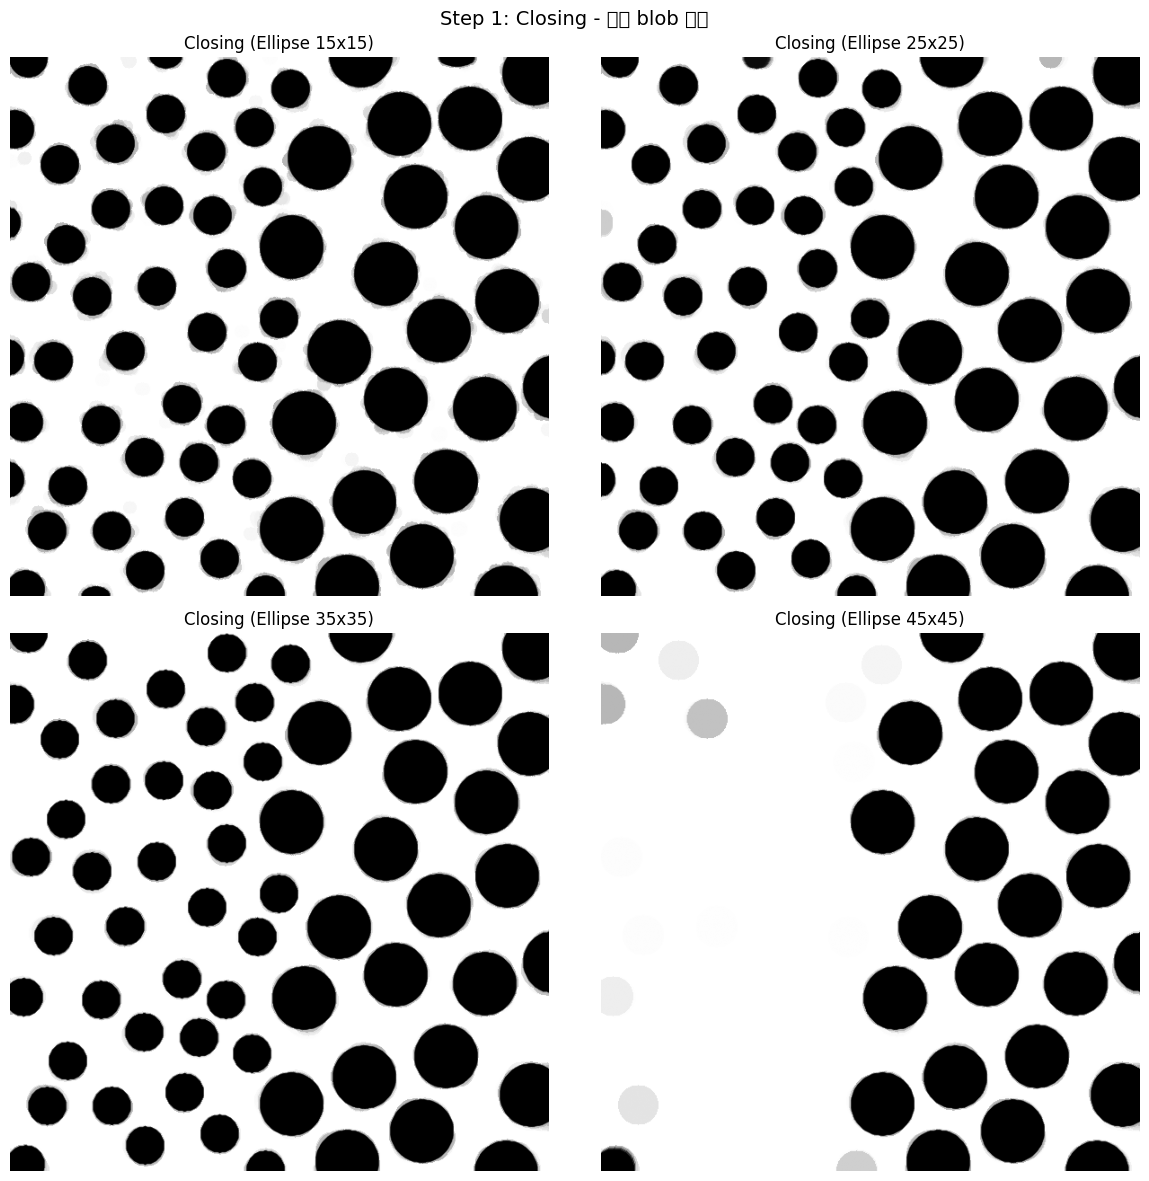

In [2]:
# 작은 blob 제거를 위한 Closing
# SE 크기를 조절하여 작은 blob만 제거
results_closing = {}
for ks in [15, 25, 35, 45]:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks, ks))
    closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
    results_closing[ks] = closed

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for i, ks in enumerate([15, 25, 35, 45]):
    r, c = divmod(i, 2)
    axes[r, c].imshow(results_closing[ks], cmap='gray')
    axes[r, c].set_title(f'Closing (Ellipse {ks}x{ks})')
    axes[r, c].axis('off')
plt.suptitle('Step 1: Closing - 작은 blob 제거', fontsize=14)
plt.tight_layout()
plt.show()

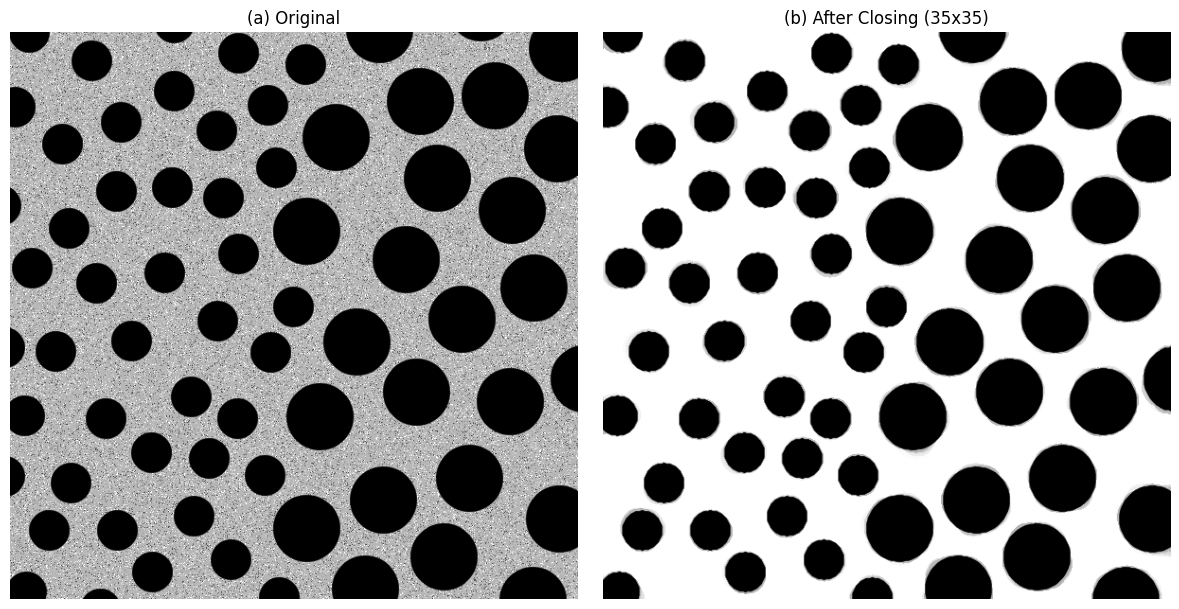

In [3]:
# 최적 SE 크기 선택 (작은 blob 제거, 큰 blob 유지)
ks_close = 35  # 필요시 조절
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks_close, ks_close))
step1_closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel_close)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('(a) Original')
axes[0].axis('off')
axes[1].imshow(step1_closed, cmap='gray')
axes[1].set_title(f'(b) After Closing ({ks_close}x{ks_close})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Step 2: Opening → 큰 blob 사이의 밝은 패치 제거

Opening(Erosion → Dilation)으로 큰 blob 사이에 남은 밝은 간격을 제거하여  
큰 blob 영역을 하나의 연결된 어두운 영역으로 만든다.

/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66294/574218665.py:15: UserWarning: Glyph 48157 (\N{HANGUL SYLLABLE BALG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66294/574218665.py:15: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66294/574218665.py:15: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66294/574218665.py:15: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66294/574218665.py:15: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66

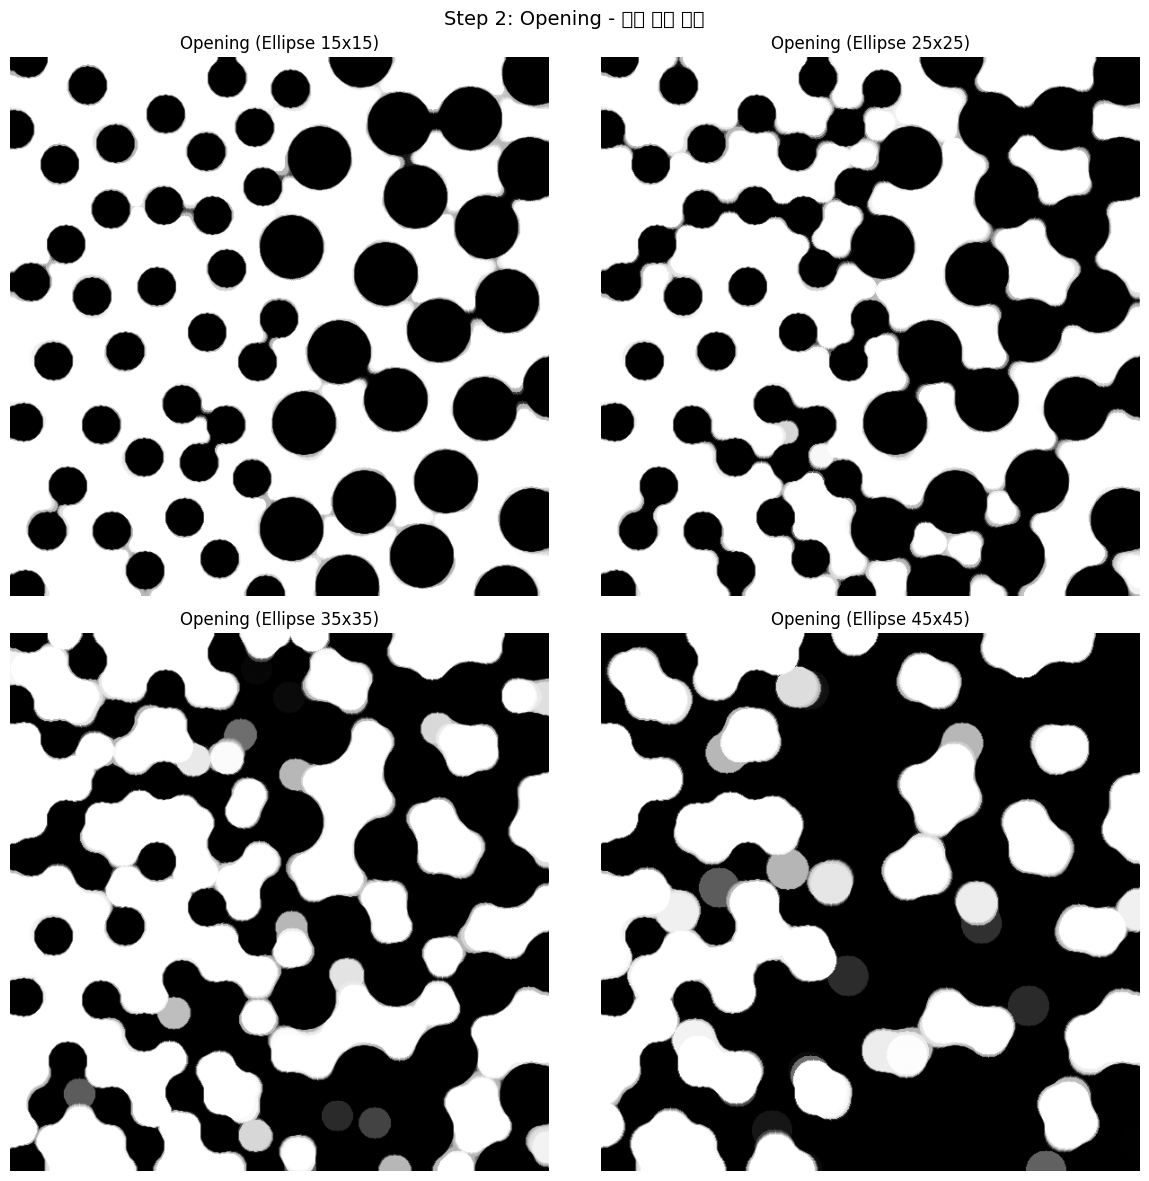

In [4]:
# Opening 적용
results_opening = {}
for ks in [15, 25, 35, 45]:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks, ks))
    opened = cv2.morphologyEx(step1_closed, cv2.MORPH_OPEN, kernel)
    results_opening[ks] = opened

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for i, ks in enumerate([15, 25, 35, 45]):
    r, c = divmod(i, 2)
    axes[r, c].imshow(results_opening[ks], cmap='gray')
    axes[r, c].set_title(f'Opening (Ellipse {ks}x{ks})')
    axes[r, c].axis('off')
plt.suptitle('Step 2: Opening - 밝은 패치 제거', fontsize=14)
plt.tight_layout()
plt.show()

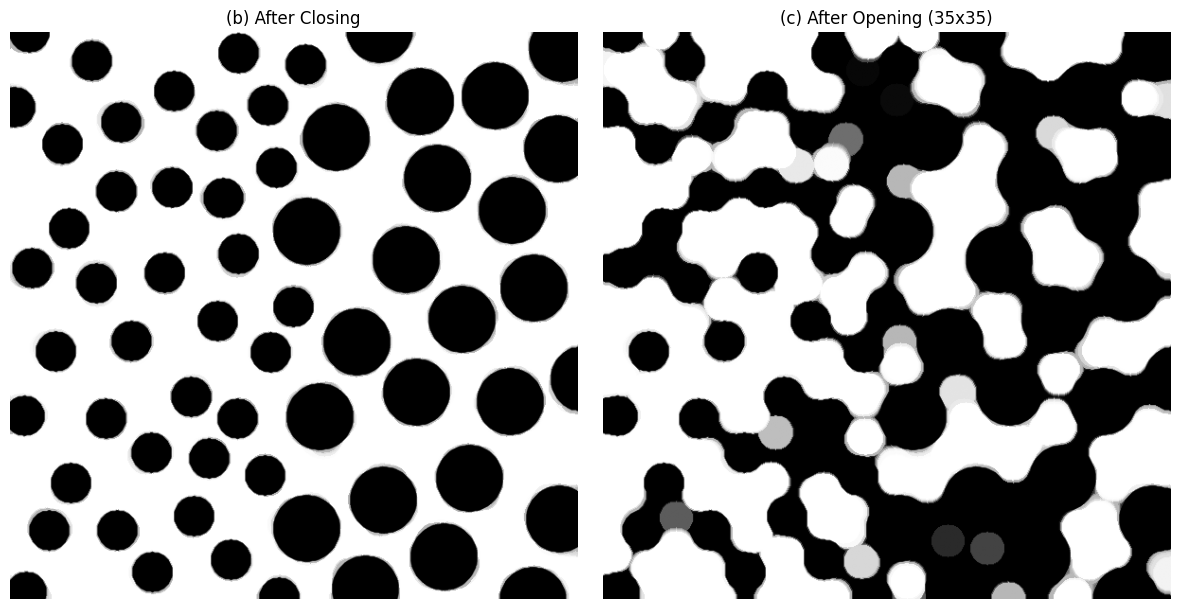

In [5]:
# 최적 SE 크기 선택
ks_open = 35  # 필요시 조절
kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ks_open, ks_open))
step2_opened = cv2.morphologyEx(step1_closed, cv2.MORPH_OPEN, kernel_open)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(step1_closed, cmap='gray')
axes[0].set_title(f'(b) After Closing')
axes[0].axis('off')
axes[1].imshow(step2_opened, cmap='gray')
axes[1].set_title(f'(c) After Opening ({ks_open}x{ks_open})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Step 3: Morphological Gradient → 경계선 추출

Step 2 결과에서 Morphological Gradient(Dilation - Erosion)로 두 영역의 경계선을 추출한다.  
이 경계선을 원본 영상 위에 중첩하여 분할 결과를 시각화한다.

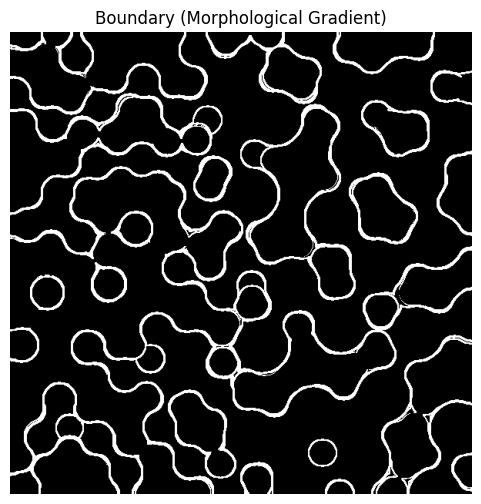

In [6]:
# Morphological Gradient로 경계 추출
kernel_grad = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
boundary = cv2.morphologyEx(step2_opened, cv2.MORPH_GRADIENT, kernel_grad)

# 경계선 이진화
_, boundary_bin = cv2.threshold(boundary, 30, 255, cv2.THRESH_BINARY)

# 원본 위에 경계선 중첩 (빨간색으로 표시하기 위해 컬러로 변환)
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
img_color[boundary_bin == 255] = [255, 255, 255]  # 경계선을 흰색으로

plt.figure(figsize=(6, 6))
plt.imshow(boundary_bin, cmap='gray')
plt.title('Boundary (Morphological Gradient)')
plt.axis('off')
plt.show()

## 전체 결과 (Figure 9.43 재현)

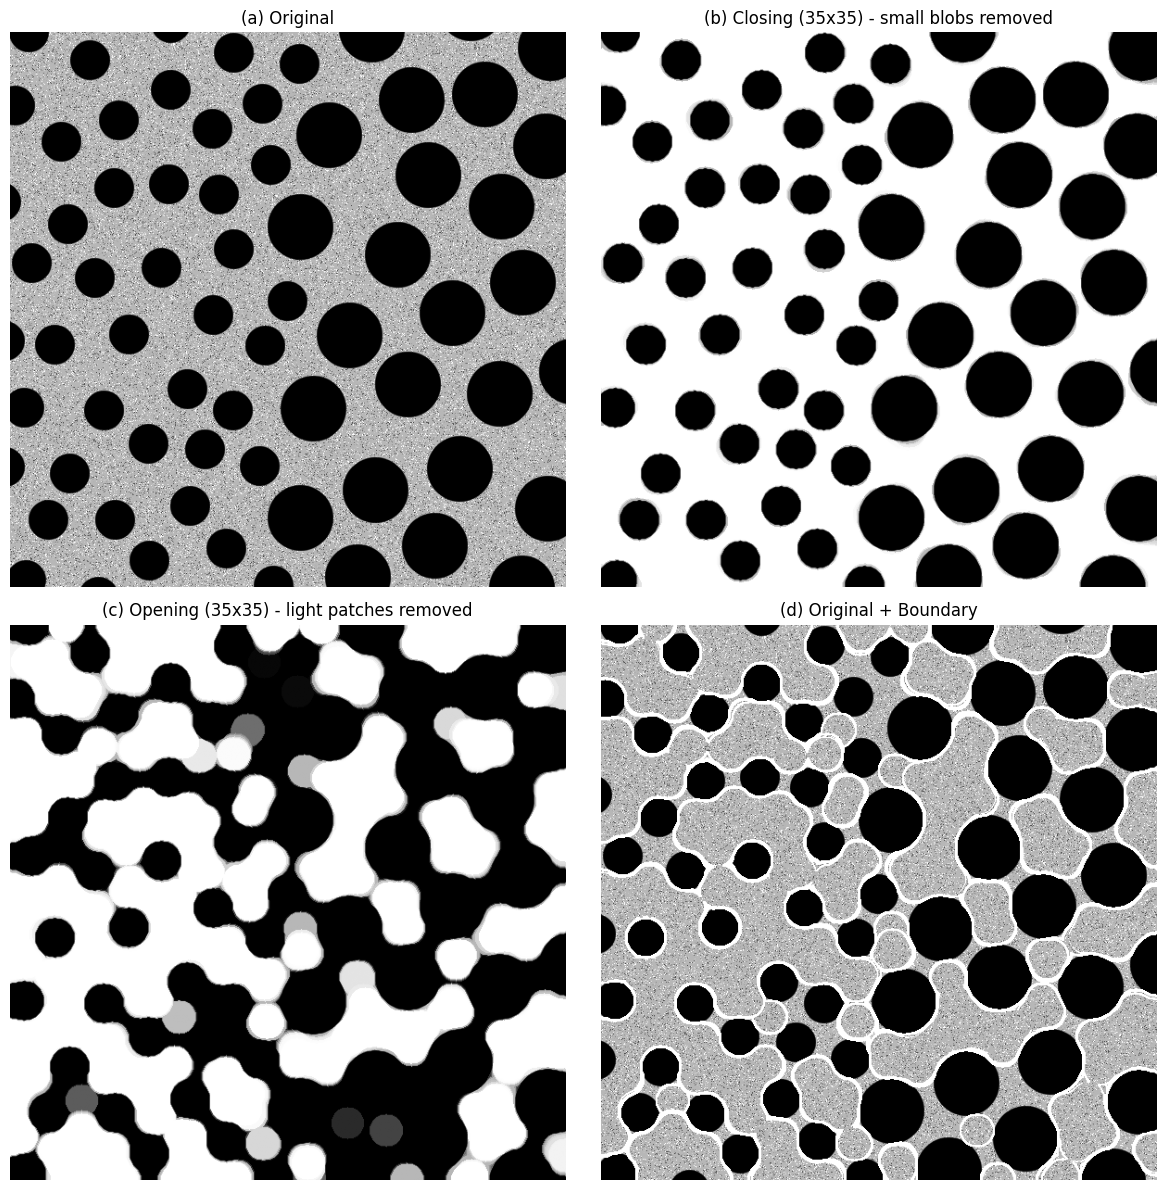

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('(a) Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(step1_closed, cmap='gray')
axes[0, 1].set_title(f'(b) Closing ({ks_close}x{ks_close}) - small blobs removed')
axes[0, 1].axis('off')

axes[1, 0].imshow(step2_opened, cmap='gray')
axes[1, 0].set_title(f'(c) Opening ({ks_open}x{ks_open}) - light patches removed')
axes[1, 0].axis('off')

# 원본에 경계 중첩
overlay = img.copy()
overlay[boundary_bin == 255] = 255
axes[1, 1].imshow(overlay, cmap='gray')
axes[1, 1].set_title('(d) Original + Boundary')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('result/hw2_10_result.png', dpi=150, bbox_inches='tight')
plt.show()

## 결과 분석

**과정 요약:**
1. **Closing:** 작은 blob(어두운 점)을 제거한다. Dilation이 작은 blob을 주변 배경으로 채우고, Erosion이 큰 blob을 원래 크기로 복원한다. SE가 작은 blob보다 크고 큰 blob보다 작아야 한다.

2. **Opening:** Closing 결과에서 큰 blob 사이에 남은 밝은 간격을 제거한다. 큰 blob들이 있는 영역이 하나의 연결된 어두운 영역으로 합쳐진다.

3. **Morphological Gradient:** Dilation - Erosion으로 두 텍스처 영역의 경계선을 추출한다. 이 경계선은 크고 작은 blob이 혼합된 영역과 큰 blob만 있는 영역을 구분한다.

**SE 크기의 중요성:**  
SE 크기가 핵심 파라미터이다. 작은 blob의 크기보다 크고, 큰 blob의 크기보다 작은 SE를 선택해야 작은 blob만 선택적으로 제거할 수 있다. SE가 너무 작으면 작은 blob이 남고, 너무 크면 큰 blob까지 손상된다.

**Morphology의 장점:**  
이 방법은 threshold 기반 분할과 달리, 객체의 크기/형태 정보를 활용하므로 밝기가 유사한 두 종류의 텍스처도 분할할 수 있다.